In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image
import cv2
from skimage.filters import sato

In [2]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4830
ROI_Y = 1710
ROI_W = 128
ROI_H = 256

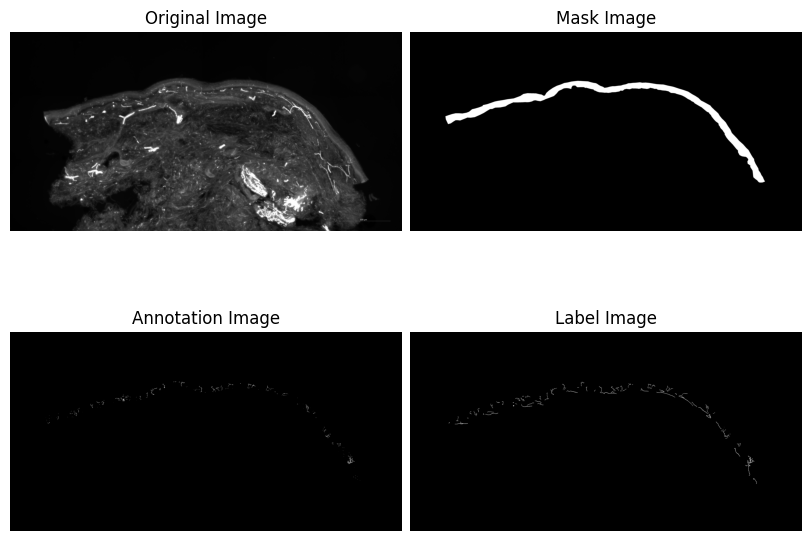

In [3]:

base_path = f"../data/{IMAGE_ID}/"

orig_img = cv2.imread(f"{base_path}/image.png")[:, :, 1]
mask_img = cv2.imread(f"{base_path}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{base_path}/annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{base_path}/label.png", cv2.IMREAD_GRAYSCALE)



_, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), constrained_layout=True)
axes[0, 0].imshow(orig_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].set_axis_off()
axes[0, 1].imshow(mask_img, cmap='gray')
axes[0, 1].set_title('Mask Image')
axes[0, 1].set_axis_off()
axes[1, 0].imshow(annotation_img, cmap='gray')
axes[1, 0].set_title('Annotation Image')
axes[1, 0].set_axis_off()
axes[1, 1].imshow(label_img, cmap='gray')
axes[1, 1].set_title('Label Image')
axes[1, 1].set_axis_off()
plt.show()

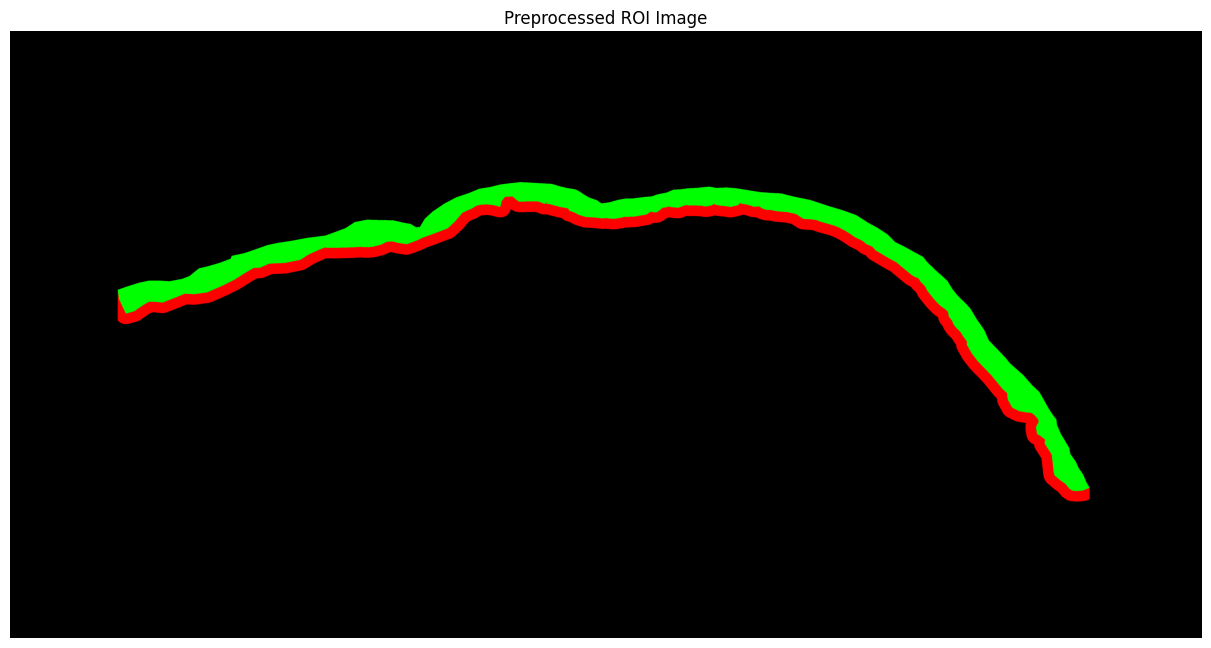

In [4]:
import cv2

mask_uint8 = mask_img.astype(np.uint8) * 255

offset_px = 100
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, offset_px * 6))
anchor = (0, offset_px*6 - 1)
dilated = cv2.dilate(mask_uint8, kernel, anchor=anchor, iterations=1)

dermis_available_mask =  dilated - mask_uint8


dermis_mask = cv2.bitwise_and(dermis_available_mask , cv2.dilate(mask_uint8, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (offset_px,offset_px)), iterations=1))
roi_mask = cv2.bitwise_or(dermis_mask.astype(np.uint8), mask_uint8.astype(np.uint8))

viz_mask = cv2.cvtColor(mask_uint8.copy(), cv2.COLOR_GRAY2BGR)
viz_mask[mask_uint8 > 0] = [0, 255, 0]
viz_mask[dermis_mask > 0] = [255, 0, 0]

_, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,8), constrained_layout=True)
axes.imshow(viz_mask)
axes.set_title('Preprocessed ROI Image')
axes.set_axis_off()
plt.show()

ROI height: 1508, width: 4591, y_start: 714, x_start: 509


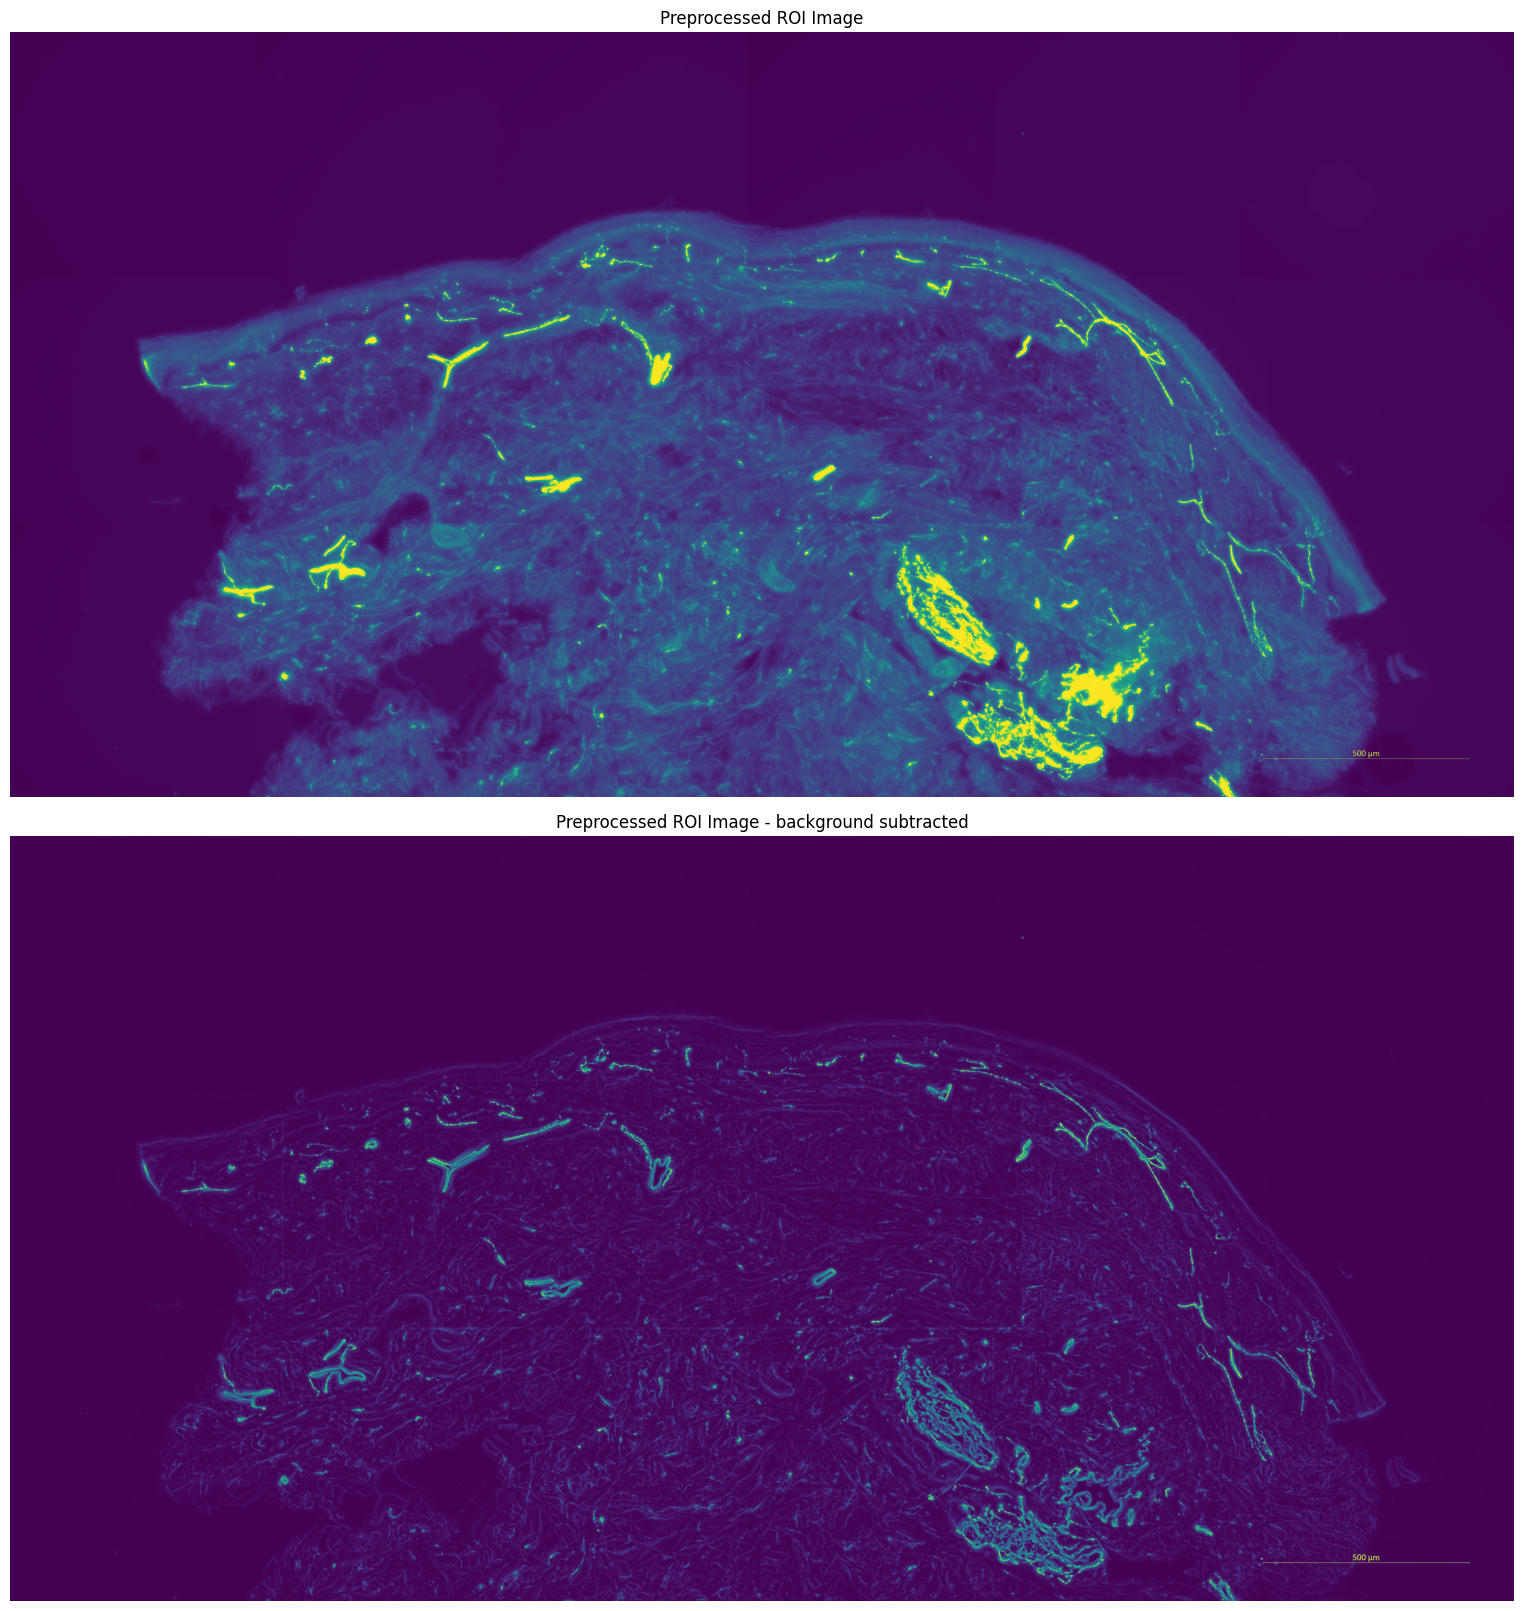

In [5]:
# Rolling ball background subtraction

_, axes = plt.subplots(nrows=2, ncols=1, figsize=(32, 16), constrained_layout=True)

image_size = orig_img.shape
y_indices, x_indices = np.where(roi_mask > 0)
padding = 0
roi_y_start = max(np.min(y_indices) - padding, 0)
roi_y_end   = min(np.max(y_indices) + padding, image_size[0])
roi_x_start = max(np.min(x_indices) - padding, 0)
roi_x_end   = min(np.max(x_indices) + padding, image_size[1])

print(f"ROI height: {roi_y_end - roi_y_start}, width: {roi_x_end - roi_x_start}, y_start: {roi_y_start}, x_start: {roi_x_start}")

axes[0].imshow(orig_img)
axes[0].set_title('Preprocessed ROI Image')
axes[0].set_axis_off()

   
# Calculate fine background (minimum of two radii)
bg_small = ski.restoration.rolling_ball(orig_img, radius=10)
bg_tiny = ski.restoration.rolling_ball(orig_img, radius=2)
bg = np.minimum(bg_small, bg_tiny)

rolling_fg = (orig_img.astype(np.uint8) - bg.astype(np.uint8)).astype(np.uint8)

sato_result = sato(
    rolling_fg.astype(np.float32),
    sigmas=range(1, 3),      # 嘗試不同尺度
    black_ridges=False,      # 偵測亮的結構
    mode='reflect'
)

# 正規化到 0-255
sato_normalized = (sato_result - sato_result.min()) / (sato_result.max() - sato_result.min() + 1e-10)
fg_img = rolling_fg + 0.5 * sato_normalized * rolling_fg.max()
fg_img = fg_img.clip(0, 255).astype(np.uint8)

axes[1].imshow(fg_img)
axes[1].set_title('Preprocessed ROI Image - background subtracted')
axes[1].set_axis_off()
plt.show()

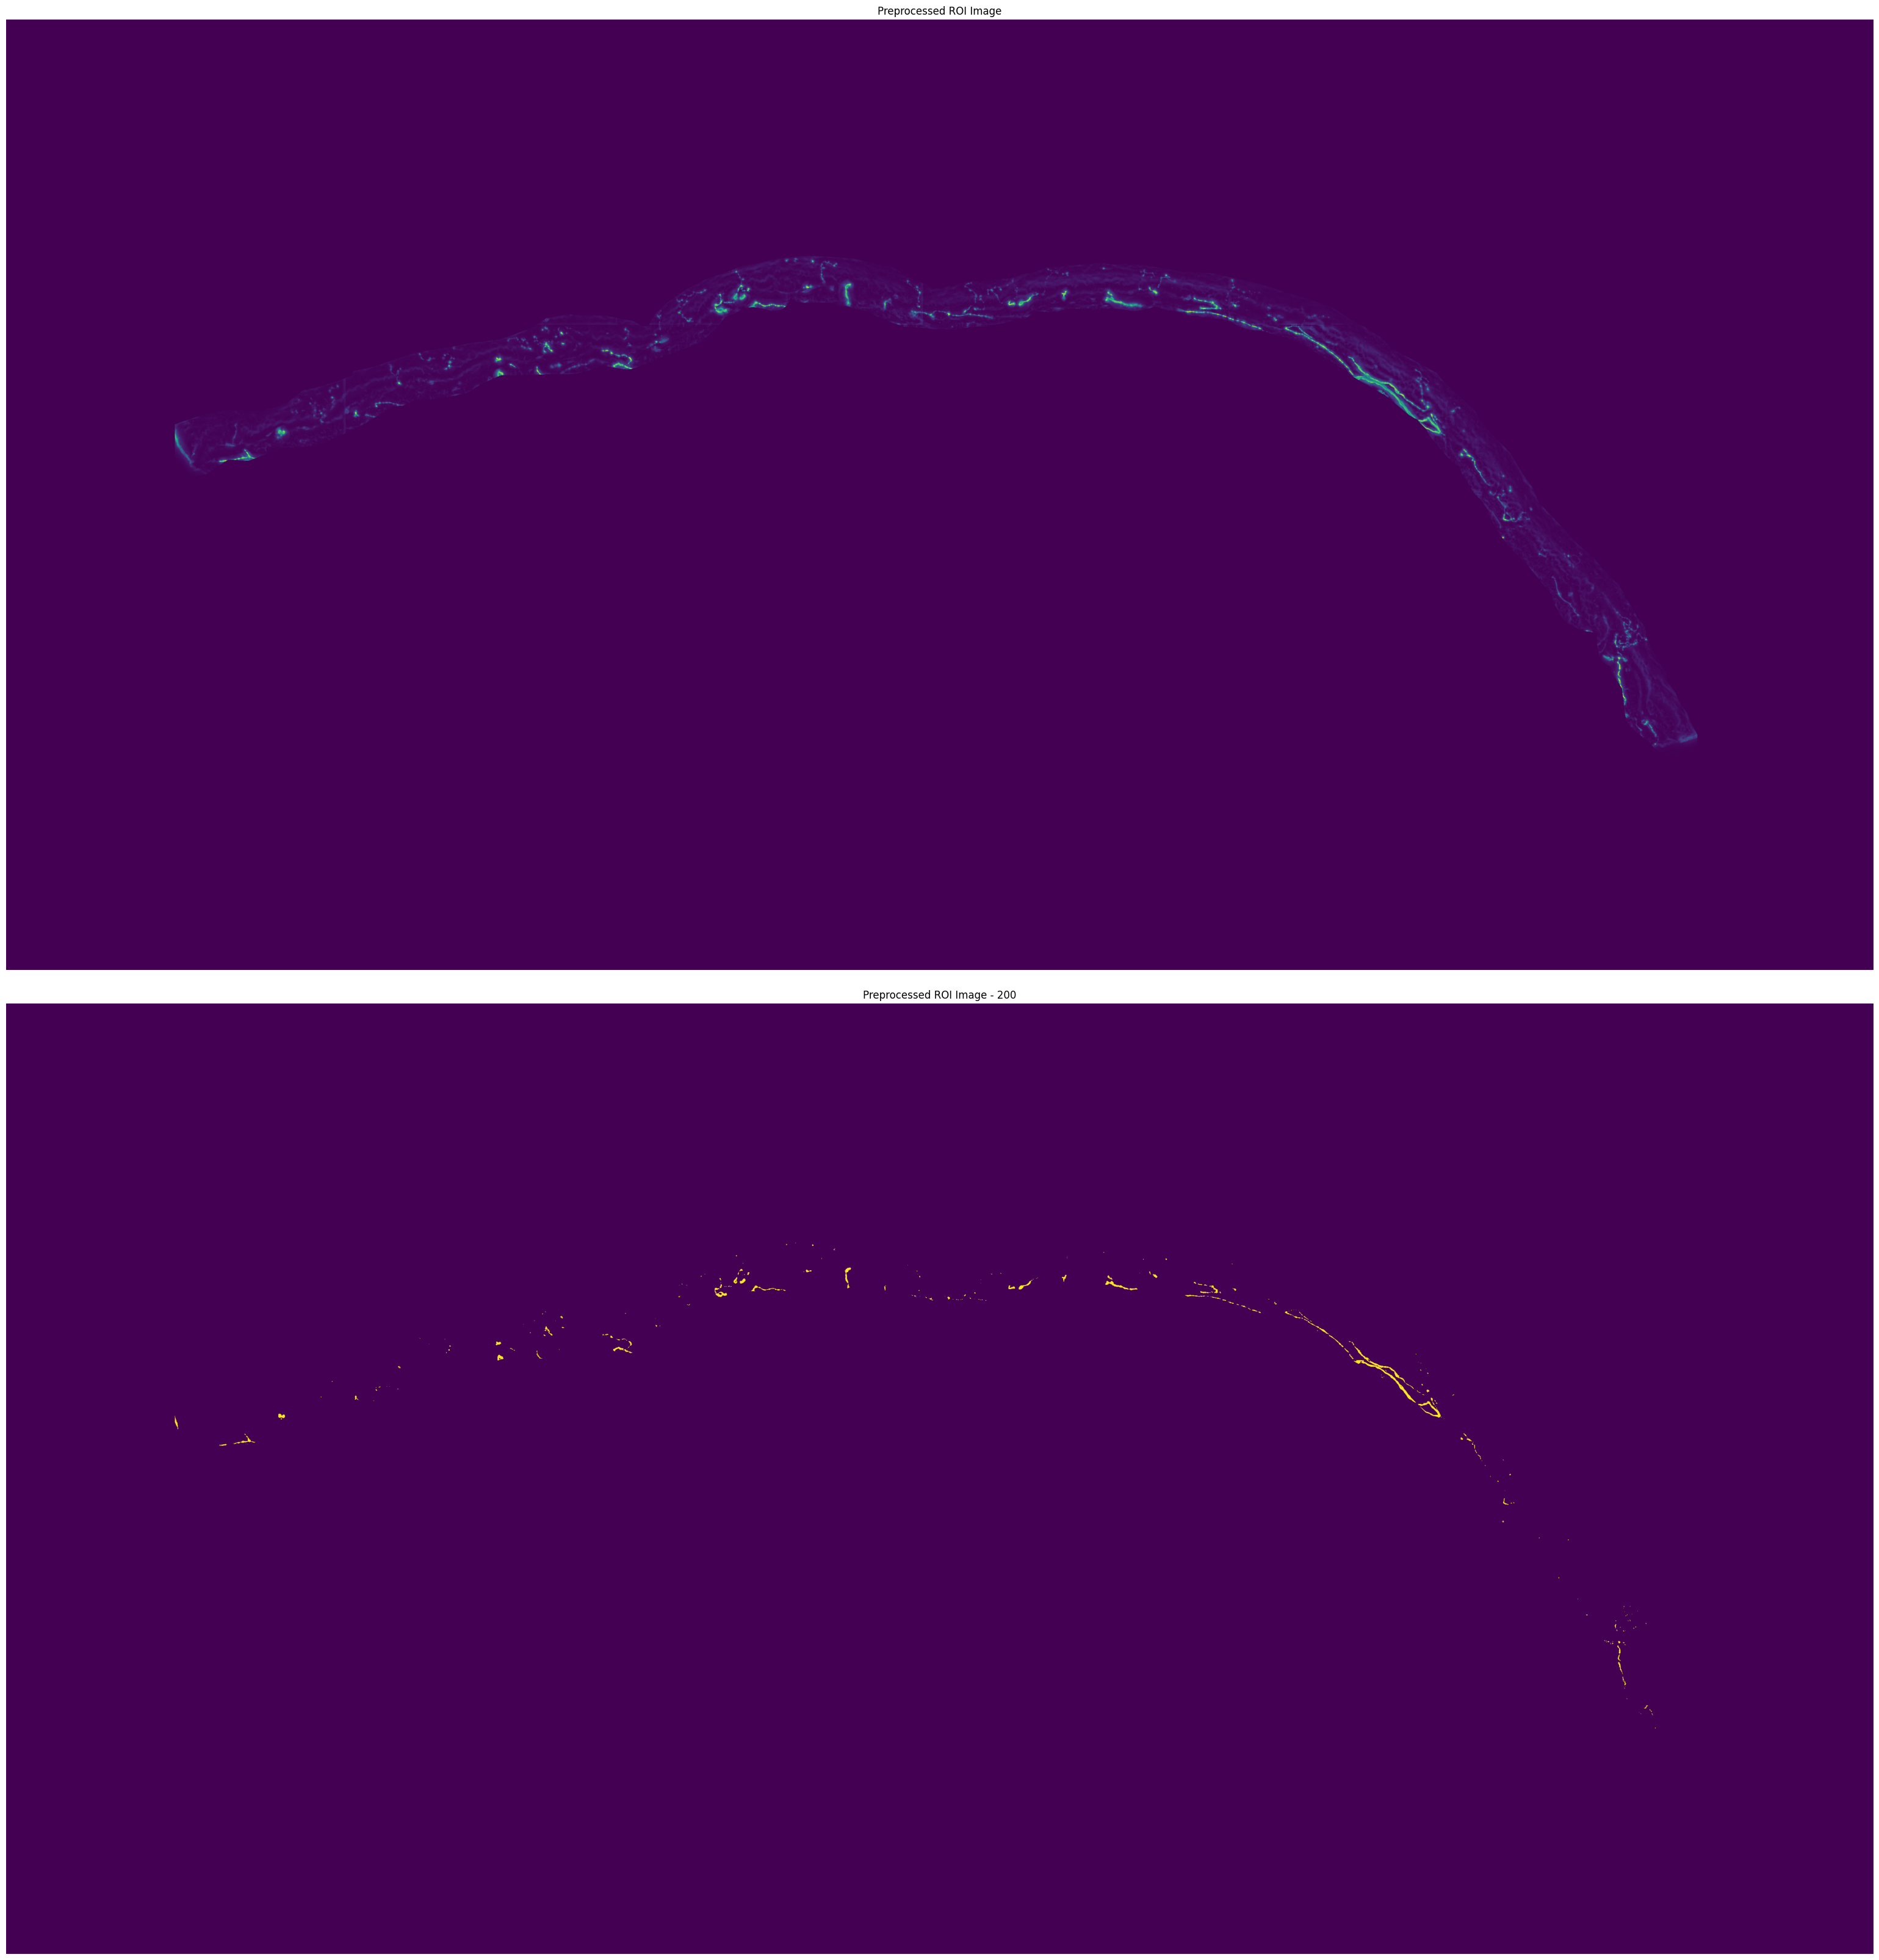

In [6]:
roi_image = cv2.bitwise_and(fg_img, fg_img, mask=roi_mask)

_, axes = plt.subplots(nrows=2, ncols=1, figsize=(32, 32), constrained_layout=True)
axes[0].imshow(roi_image)
axes[0].set_title('Preprocessed ROI Image')
axes[0].set_axis_off()

thresholds = ski.filters.threshold_multiotsu(roi_image)
regions = np.digitize(roi_image, bins=thresholds)

toplevel_mask = (regions == len(thresholds)).astype(np.uint8)

cv = ski.segmentation.chan_vese(
    roi_image.astype(np.float32),
    mu=0,
    lambda1=10,
    lambda2=1,
    tol=1e-4,
    max_num_iter=200,
    dt=0.5,
    init_level_set=toplevel_mask.astype(np.float32),
    extended_output=True,
)

axes[1].imshow(cv[0])
axes[1].set_title(f"Preprocessed ROI Image - {len(cv[2])}")
axes[1].set_axis_off()

plt.show() 

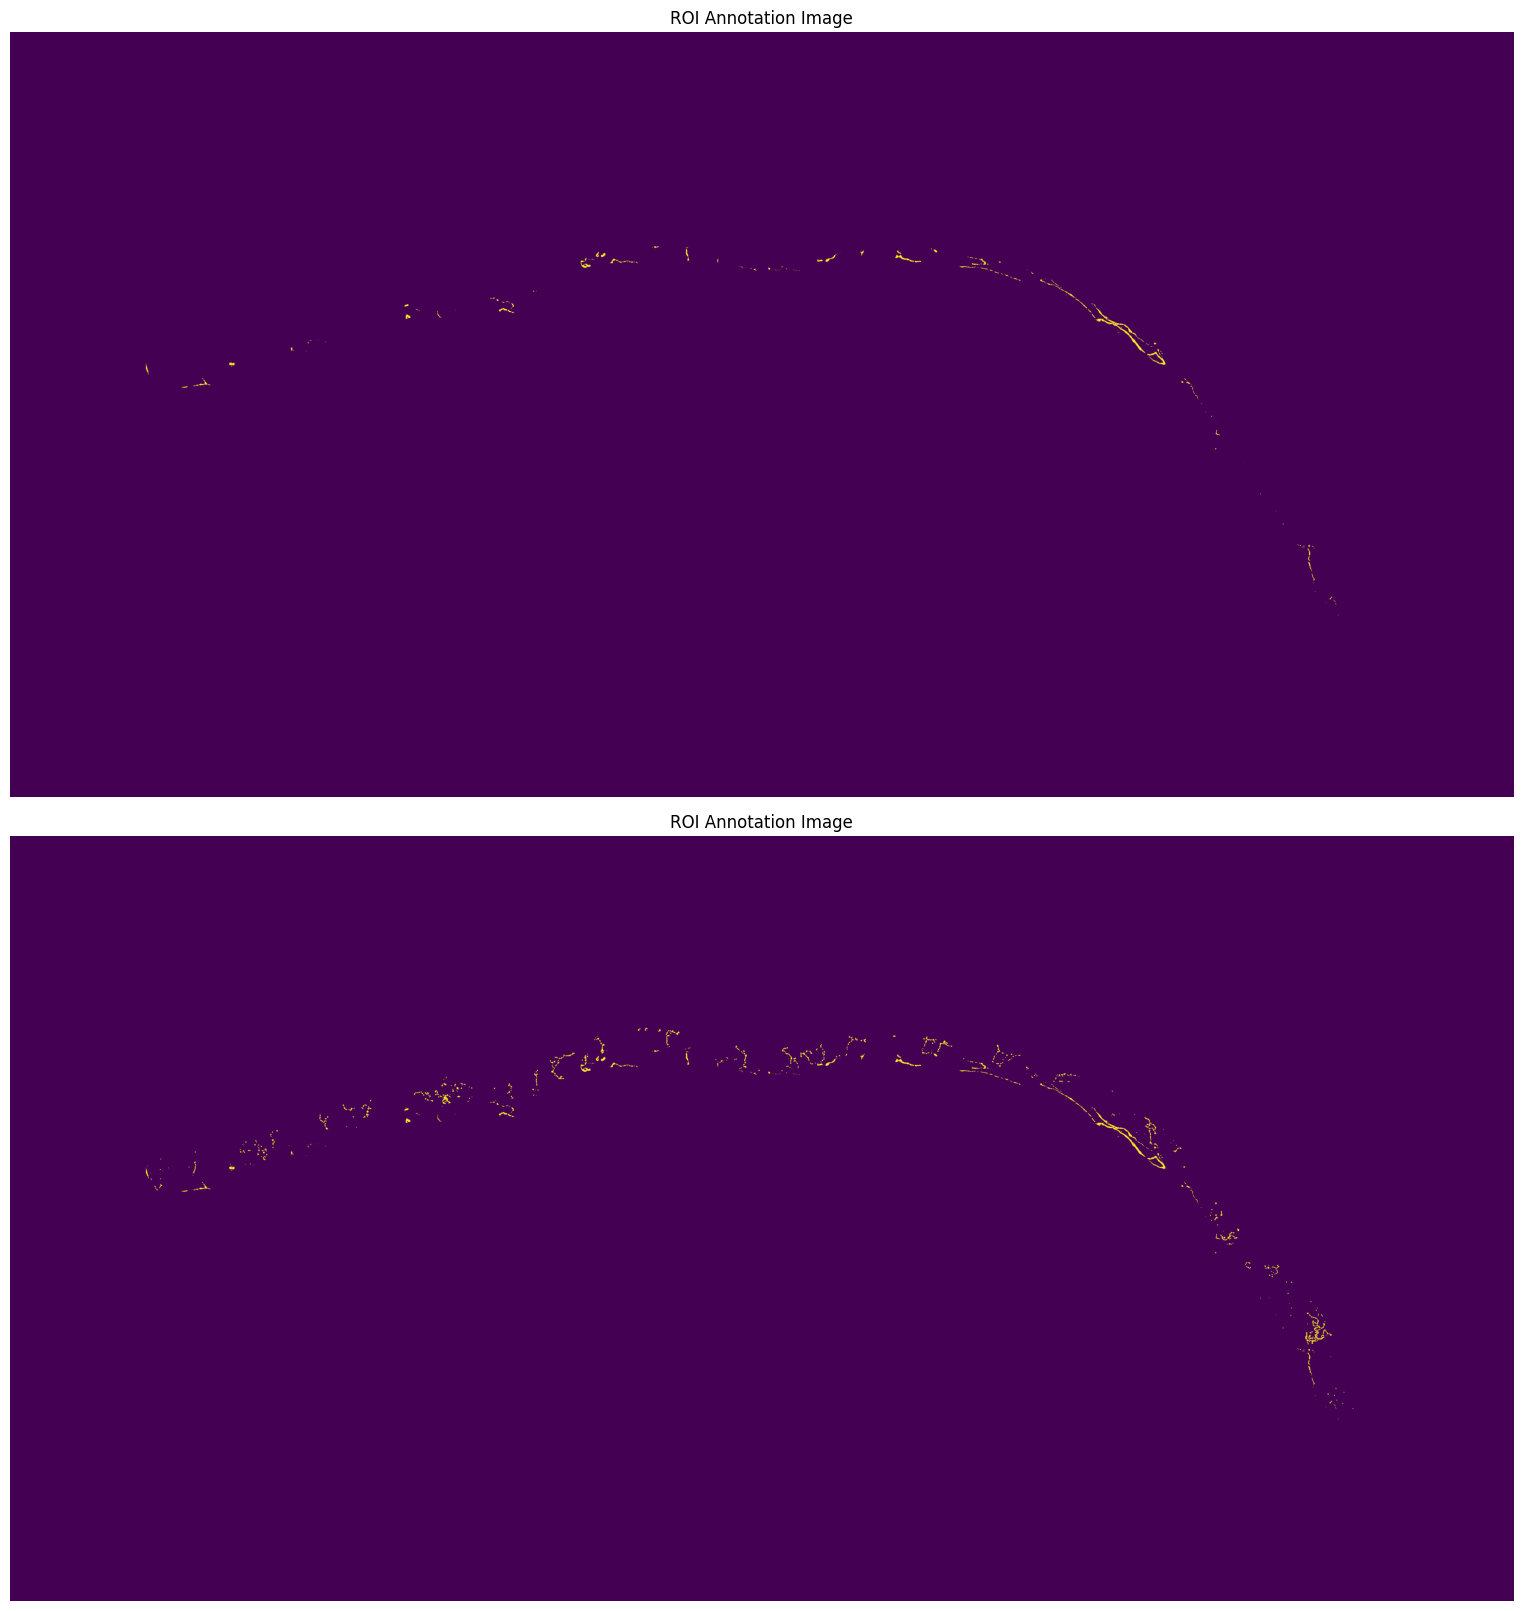

In [7]:
chanvese_mask = (cv[0] > 0).astype(np.uint8)


dermis_annotation = cv2.bitwise_and(chanvese_mask,chanvese_mask, mask=dermis_mask)

roi_annotation = cv2.bitwise_or(dermis_annotation, (annotation_img>0).astype(np.uint8))

_, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 16), constrained_layout=True)
axes[0].imshow(dermis_annotation)
axes[0].set_title('ROI Annotation Image')
axes[0].set_axis_off()


axes[1].imshow(roi_annotation)
axes[1].set_title('ROI Annotation Image')
axes[1].set_axis_off()

plt.show()

Total components detected: 791


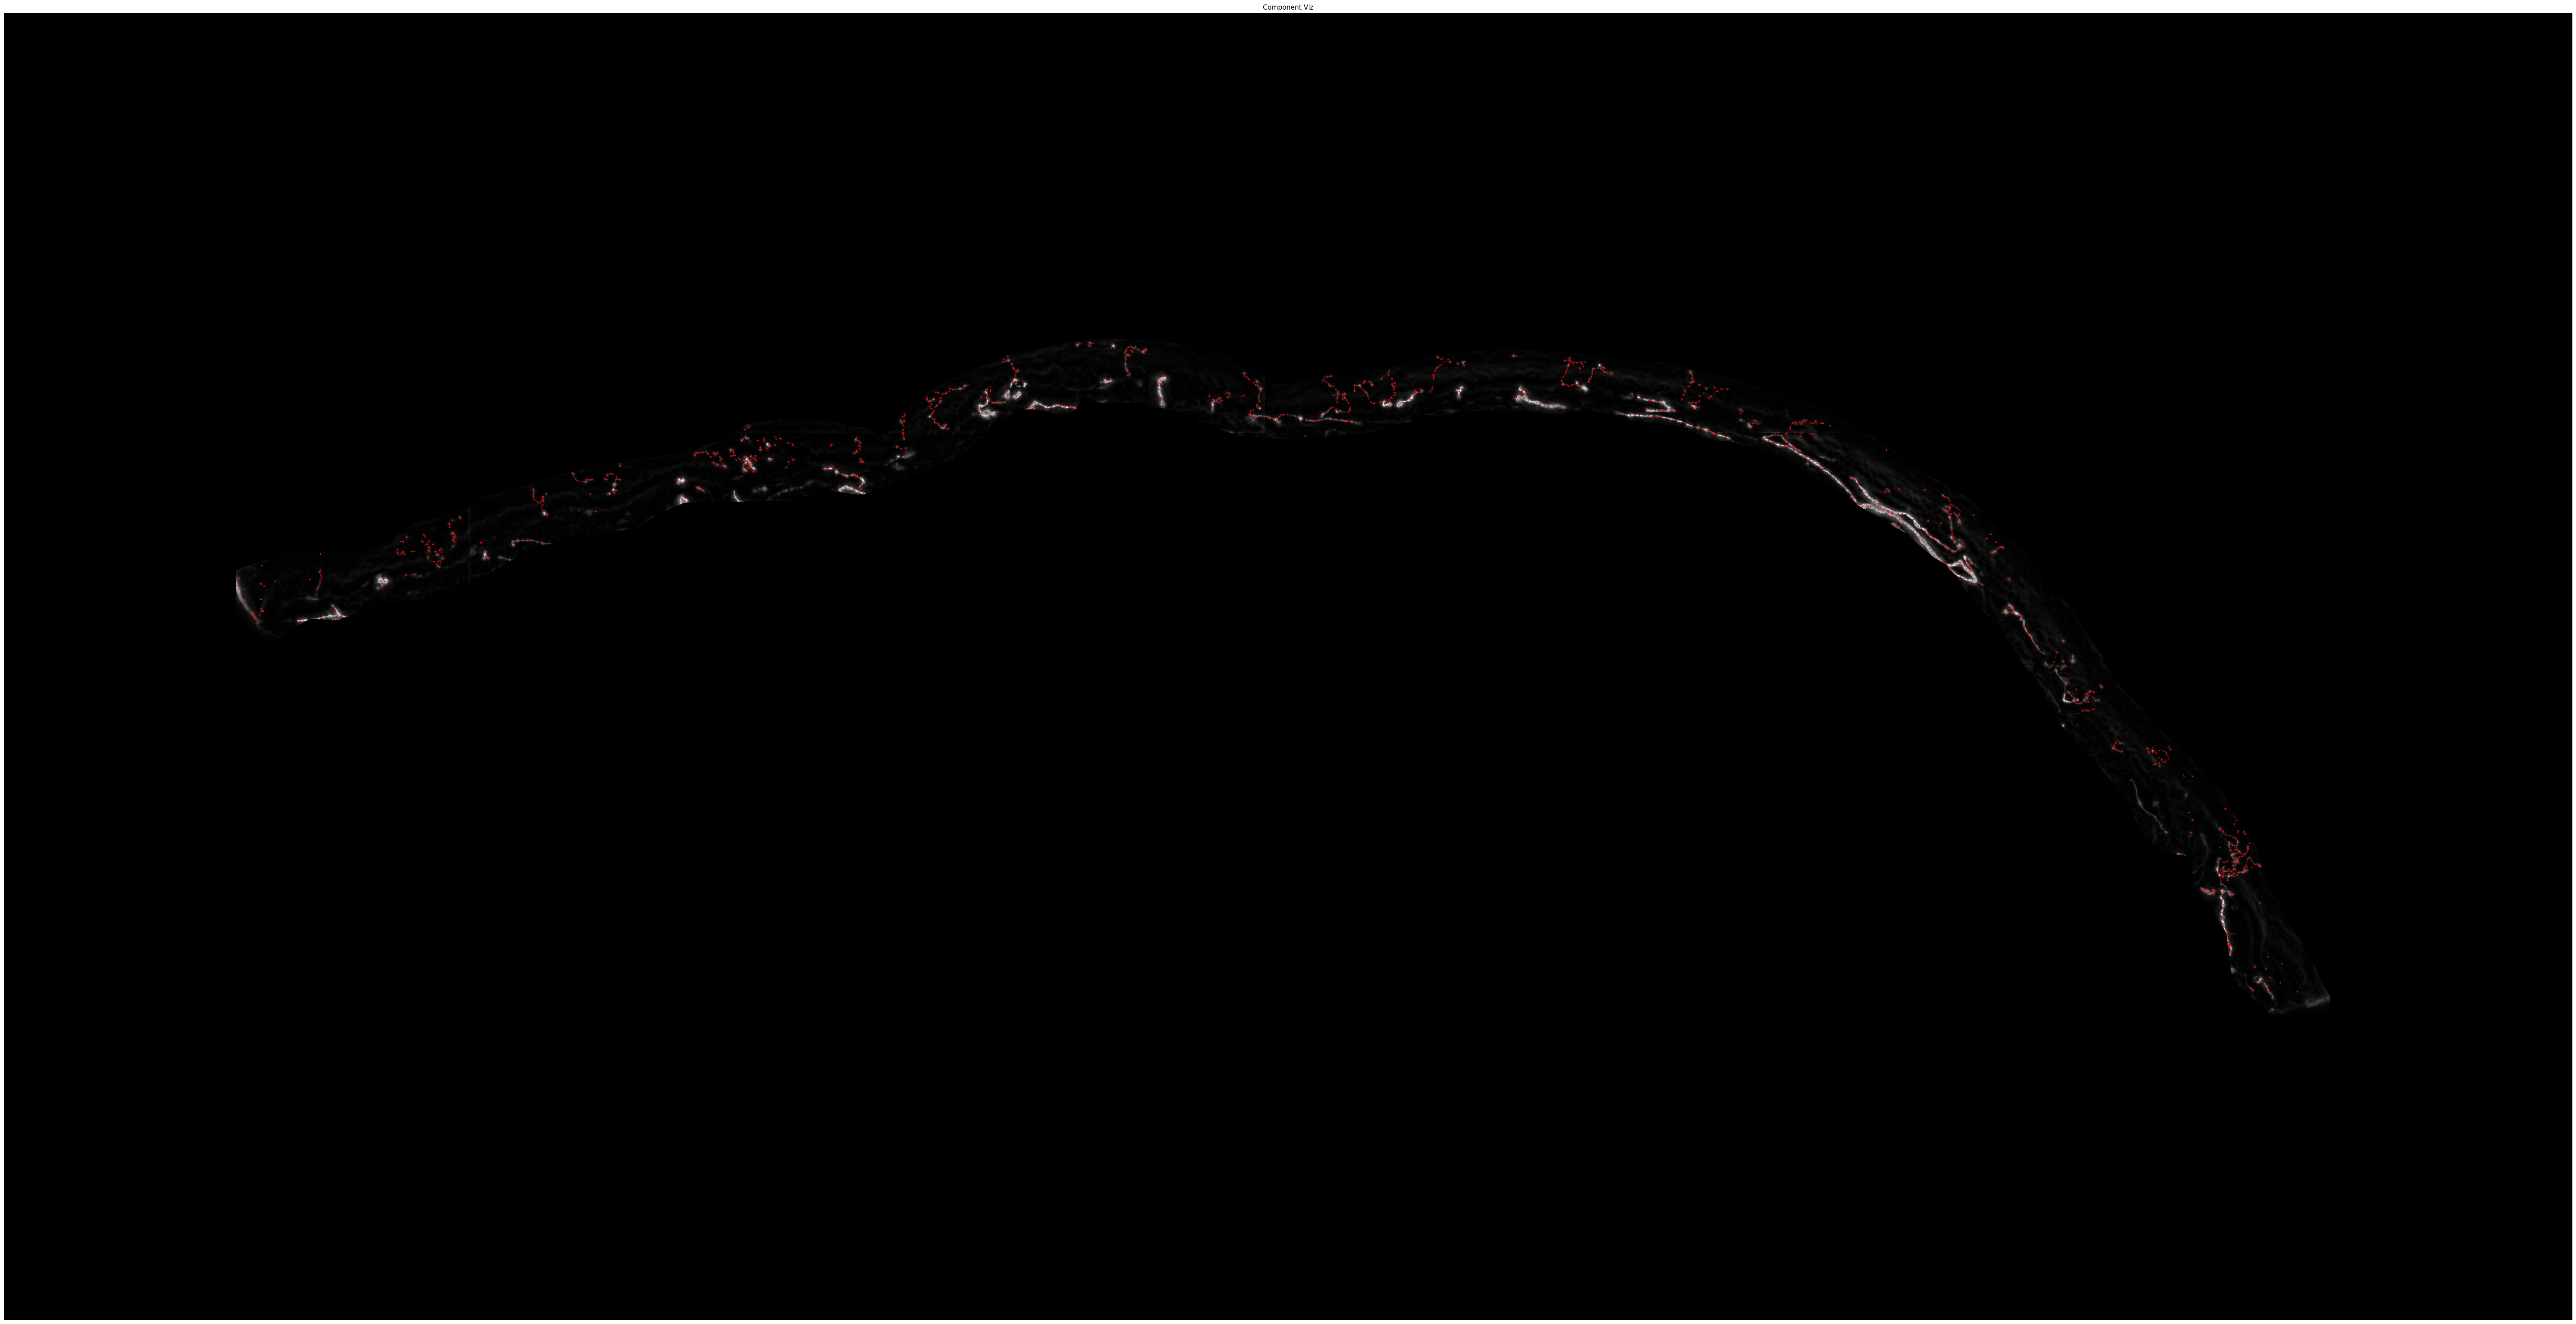

In [8]:
import cv2
from skimage.measure import label, regionprops
from neural_reconstruction.core.construction.component_analyzer import ComponentAnalyzer
from neural_reconstruction.common.data_types import ComponentAnalysisResult
from typing import List

annotation_mask = (roi_annotation > 0).astype(np.uint8)
labeled_image = label(annotation_mask, connectivity=1)
regions = regionprops(labeled_image)


component_analyzer = ComponentAnalyzer(
    segment_length=10,
    min_edge_length=0,
    prune_threshold=0,
    spacing=0,
)

component_list:List[ComponentAnalysisResult] =[]
for region in regions:
	component_analyze_res = component_analyzer.analyze(region)
	component_list.append(component_analyze_res)


print(f"Total components detected: {len(component_list)}")

# Viz first five components

fig_size = 64
num_fig = 1
_, axes = plt.subplots(nrows=num_fig, ncols=1, figsize=(fig_size, fig_size * num_fig), constrained_layout=True)
component_image =cv2.cvtColor(roi_image.copy(), cv2.COLOR_GRAY2BGR)

seed_points = []
axes.imshow(component_image)
# for i in range(10):
for component in component_list:
	# component = component_list[i]
	bbox = component.bbox  # (min_row, min_col, max_row, max_col)
	min_row, min_col, max_row, max_col = bbox


	for node in component.topology.nodes():
		py, px = node
		py += min_row
		px += min_col

		seed_points.append((py, px))
		
		axes.plot(px, py, 'ro', markersize=1)

axes.set_title(f'Component Viz')
axes.set_axis_off()

plt.show()

In [9]:
from sklearn.cluster import DBSCAN

seed_points = np.array(seed_points)

# 計算每個 seed point 的 intensity
intensities = np.array([roi_image[py, px] for py, px in seed_points])

clustering = DBSCAN(eps=2, min_samples=1).fit(seed_points)
    
selected_points = []
selected_intensities = []

labels = clustering.labels_
unique_labels = set(clustering.labels_)

fig_size = 256
_, ax = plt.subplots(nrows=1, ncols=1, figsize=(fig_size, fig_size), constrained_layout=True)
ax.imshow(roi_image)

# 為每個聚類生成不同的顏色
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

clustered_points = []
for idx, label in enumerate(unique_labels):
	mask = labels == label
	cluster_points = seed_points[mask]
	cluster_intensities = intensities[mask]
	
	if label == -1:
		# 噪声点：全部保留（孤立的种子），用灰色顯示
		for i in range(len(cluster_points)):
			selected_points.append(cluster_points[i])
			selected_intensities.append(cluster_intensities[i])
		ax.scatter(cluster_points[:, 1], cluster_points[:, 0], 
				   c='gray', s=10, marker='x', alpha=0.5, label='Noise')
	else:
		# 聚类内：选择最亮的点
		brightest_idx = np.argmax(cluster_intensities)
		selected_points.append(cluster_points[brightest_idx])
		selected_intensities.append(cluster_intensities[brightest_idx])
		
		# 視覺化：顯示聚類中的所有點（小圓點）
		ax.scatter(cluster_points[:, 1], cluster_points[:, 0], 
				   c=[colors[idx]], s=15, marker='o', alpha=0.3)
		
		# 標記選中的最亮點（大紅點）
		brightest_point = cluster_points[brightest_idx]
		ax.scatter(brightest_point[1], brightest_point[0], 
				   c='red', s=50, marker='*', edgecolors='white', linewidths=0.1)
		

ax.set_title(f'DBSCAN Clustering: {len(unique_labels)} clusters, {len(selected_points)} selected points')
ax.set_axis_off()
plt.show()

print(f"Original seed points: {len(seed_points)}")
print(f"Selected points after clustering: {len(selected_points)}")

Original seed points: 2289
Selected points after clustering: 1513


In [10]:
from scipy.spatial import KDTree
from neural_reconstruction.core.construction.connection_graph_builder.path_finder import Pathfinder

# 參數設定
SEARCH_RADIUS = 20  # 搜尋半徑
NUM_BUCKETS = 12    # 方向桶數量（每個桶 30 度）

# 將 selected_points 轉換為 numpy array
selected_points = np.array(selected_points)

# 建構 KDTree
kdtree = KDTree(selected_points)

print(f"KDTree built with {len(selected_points)} points")
print(f"Search radius: {SEARCH_RADIUS}, Number of buckets: {NUM_BUCKETS}")

KDTree built with 1513 points
Search radius: 20, Number of buckets: 12


In [11]:
# Find very pairings 
cost_map = (255 - roi_image.astype(np.float64))**2 / 255**2
cost_map_h, cost_map_w = cost_map.shape

path_finding_bbox_padding = 10
pairings = {}

for u_idx in range(len(selected_points)):
	search_radius = SEARCH_RADIUS
	# 在 KDTree 中搜尋鄰近點
	u = selected_points[u_idx]
    
    # 查詢半徑內的所有鄰居
	neighbor_indices = kdtree.query_ball_point(u, r=search_radius)
    
    # 排除自己
	neighbor_indices = [idx for idx in neighbor_indices if idx != u_idx]
    
    
	targets = [selected_points[v_idx] for v_idx in neighbor_indices]
	# 計算包含所有點的最小 bbox + padding
	all_points = [u] + targets
	all_y = [p[0] for p in all_points]
	all_x = [p[1] for p in all_points]

	min_y = max(0, min(all_y) - path_finding_bbox_padding)
	max_y = min(cost_map_h - 1, max(all_y) + path_finding_bbox_padding)
	min_x = max(0, min(all_x) - path_finding_bbox_padding)
	max_x = min(cost_map_w - 1, max(all_x) + path_finding_bbox_padding)

	cropped_cost_map = cost_map[min_y : max_y + 1, min_x : max_x + 1]

	
	local_points = [(pos_global[0] - min_y, pos_global[1] - min_x) for pos_global in all_points]
	mcp = ski.graph.MCP_Geometric(cropped_cost_map, fully_connected=True)
	cumulative_costs, traceback = mcp.find_costs(starts=local_points[:1], ends=local_points[1:])
	for target in local_points[1:]:
		if np.isinf(cumulative_costs[target]):
			continue

		path = mcp.traceback(target)
		cost = cumulative_costs[target]
		path_arr = np.array(path)
		diffs = np.diff(path_arr, axis=0)
		segment_dists = np.linalg.norm(diffs, axis=1)
		path_length = np.sum(segment_dists)
		# 轉換回全局座標
		global_path = [(p[0] + min_y, p[1] + min_x) for p in path]
		global_start = (u[0], u[1])
		global_target = (target[0] + min_y, target[1] + min_x)
		normalized_cost = cost / path_length

		if (global_target, global_start) in pairings:
			min_cost = min(pairings[(global_target, global_start)][1], normalized_cost)
			pairings[(global_target, global_start)] = (global_path, min_cost)
		else:
			pairings[(global_start, global_target)] = (global_path, normalized_cost)


In [ ]:

fig_size = 256
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(fig_size, fig_size // 2), constrained_layout=True)

# 繪製背景圖片
ax.imshow(roi_image, cmap='gray')

# 繪製所有種子點
unique_seeds = set()
for (p1, p2), (path, cost) in pairings.items():
    unique_seeds.add(p1)
    unique_seeds.add(p2)

unique_seeds = list(unique_seeds)
seed_y = [s[0] for s in unique_seeds]
seed_x = [s[1] for s in unique_seeds]
ax.scatter(seed_x, seed_y, c='cyan', s=5, alpha=0.6, zorder=2, label='Seeds')

# 繪製所有連接路徑
# 使用成本來決定顏色（從藍色到紅色）
all_costs = [cost for _, (path, cost) in pairings.items()]
min_cost = min(all_costs)
max_cost = max(all_costs)

# 使用 colormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

norm = Normalize(vmin=min_cost, vmax=max_cost)
cmap = plt.cm.viridis  # 可以選擇其他 colormap: 'viridis', 'plasma', 'inferno', 'coolwarm'

for (p1, p2), (path, cost) in pairings.items():
    if path and len(path) > 1:
        # 繪製路徑
        py = [p[0] for p in path]
        px = [p[1] for p in path]
        
        # 根據成本決定顏色
        color = cmap(norm(cost))
        ax.plot(px, py, color=color, alpha=0.4, linewidth=1, zorder=1)

ax.set_title(f'All Pairings Visualization: {len(pairings)} connections')
ax.set_axis_off()

plt.show()

# 輸出統計資訊
print(f"\n=== 視覺化統計 ===")
print(f"總連接數: {len(pairings)}")
print(f"涉及種子數: {len(unique_seeds)}")
print(f"成本範圍: [{min_cost:.2f}, {max_cost:.2f}]")

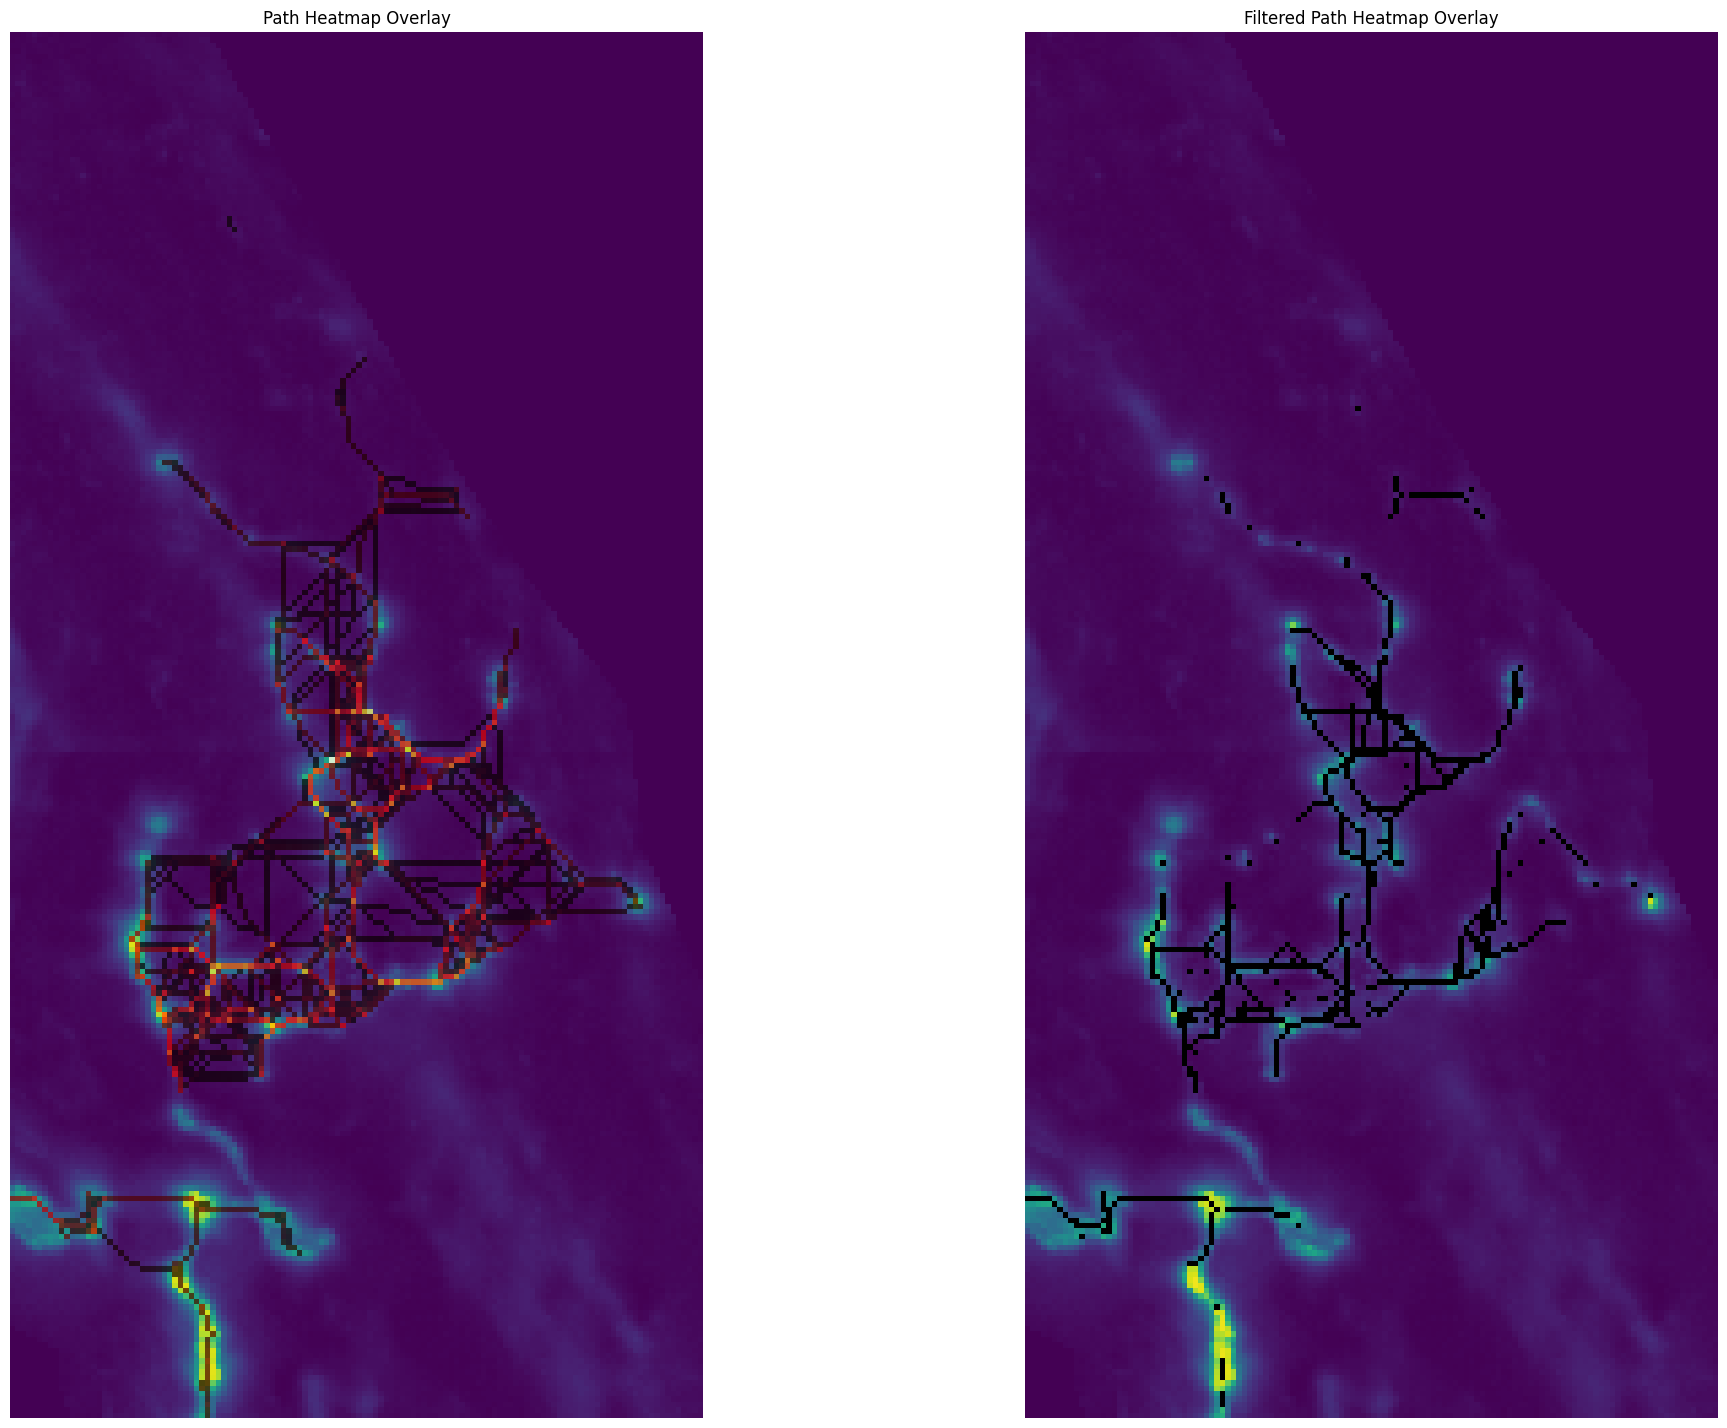

In [ ]:
path_heatmap = np.zeros_like(roi_image, dtype=np.float64)
for (p1, p2), (path, cost) in pairings.items():
    for (py, px) in path:
        path_heatmap[py, px] += 1   
_, ax = plt.subplots(1, 2, figsize=(24, 18))

heatmap_ax = ax[0]
heatmap_ax.imshow(roi_image[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
heatmap_ax.imshow(np.ma.masked_where(path_heatmap == 0, path_heatmap)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='hot', alpha=0.7)
heatmap_ax.set_title("Path Heatmap Overlay")
heatmap_ax.axis('off')


heatmap_thershold = np.quantile(path_heatmap[path_heatmap > 0], 0.75)
filtered_path_heatmap = (path_heatmap >= heatmap_thershold).astype(np.uint8)
heatmap_ax2 = ax[1]
heatmap_ax2.imshow(roi_image[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
heatmap_ax2.imshow(np.ma.masked_where(filtered_path_heatmap == 0, filtered_path_heatmap)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray', alpha=1)
heatmap_ax2.set_title("Filtered Path Heatmap Overlay")
heatmap_ax2.axis('off')

plt.show()


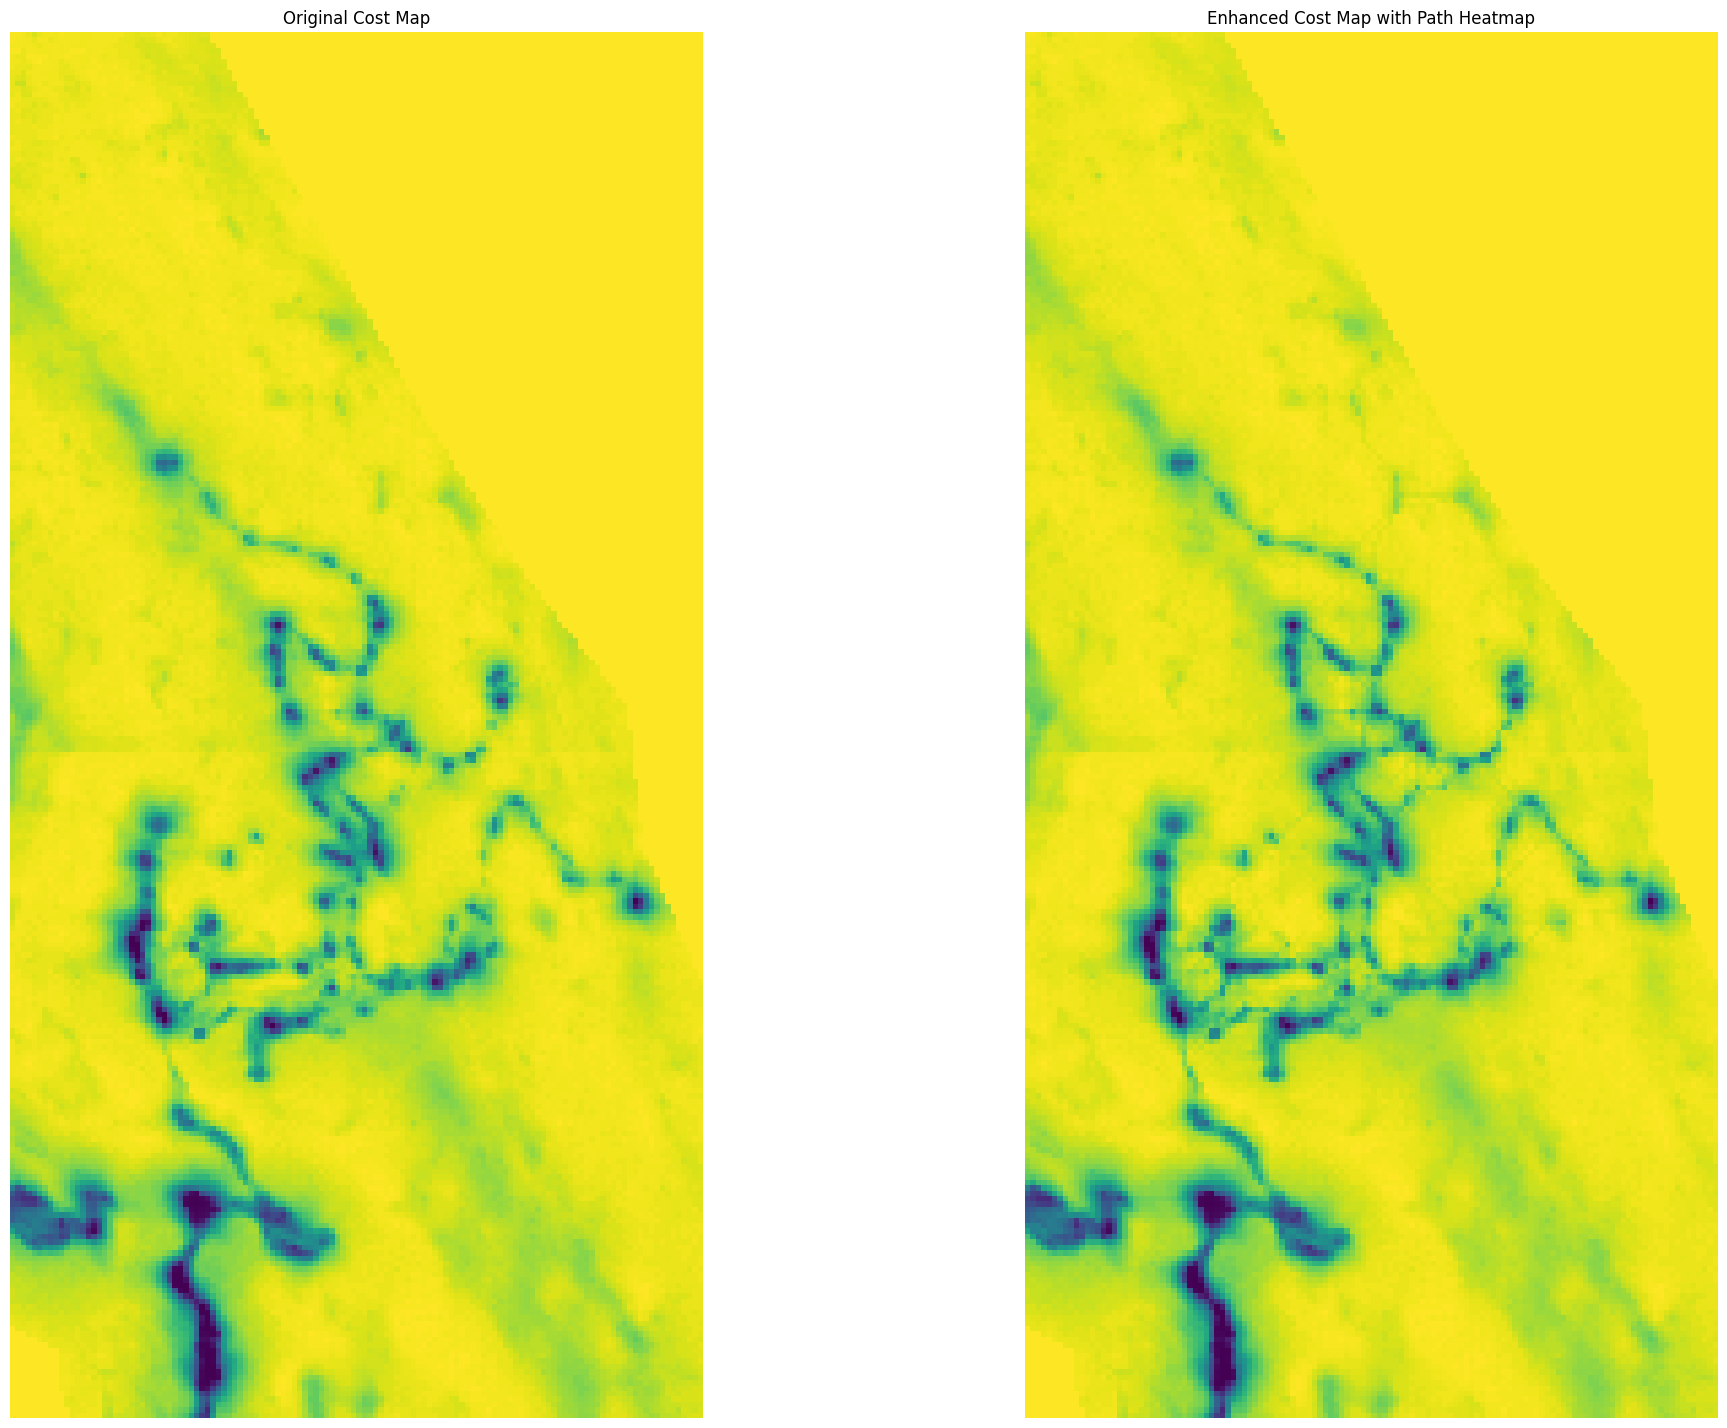

In [ ]:
from scipy.ndimage import binary_dilation, distance_transform_edt


heatmap_norm = path_heatmap / (path_heatmap.max() + 1e-6)
high_heat_mask = heatmap_norm > 0.7
dist_to_heat = distance_transform_edt(~high_heat_mask)
            
# 距離衰減：在 dilation_radius 內線性衰減
# dist=0 → weight=1, dist=radius → weight=0
distance_weight = np.clip(1 - dist_to_heat /8, 0, 1)

# 組合：原始熱度 + 距離衰減帶來的擴展
heatmap_enhanced = np.maximum(heatmap_norm, distance_weight * 0.5)
heatmap_enhanced = heatmap_enhanced / heatmap_enhanced.max()
# 係數 0.6: 強烈貼合共識
enhanced_cost = cost_map * (1 - 0.6 * heatmap_enhanced)

_, ax = plt.subplots(1, 2, figsize=(24, 18))
ax[0].imshow(cost_map[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
ax[0].set_title("Original Cost Map")
ax[0].axis('off')
ax[1].imshow(enhanced_cost[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
ax[1].set_title("Enhanced Cost Map with Path Heatmap")
ax[1].axis('off')
plt.show()

In [ ]:
enhanced_parings = {}

enhance_mcp = ski.graph.MCP_Geometric(enhanced_cost, fully_connected=True)


seed_pairing_lookup = {}

for (s1, s2), (path, cost) in pairings.items():
    if s1 not in seed_pairing_lookup:
        seed_pairing_lookup[s1] = [s2]
    else:
        seed_pairing_lookup[s1].append(s2)


for s1, targets in seed_pairing_lookup.items():
    # cumulative_costs, traceback = enhance_mcp.find_costs(starts=[s1], ends=targets)
    
    for s2 in targets:
        # path = enhance_mcp.traceback(s2  )
        path, cost = pairings[(s1, s2)]
        
        if len(path) == 0:
            continue
        
        # 用原始 heatmap 評分
        heat_values = [path_heatmap[p] for p in path]
        avg_heat = np.mean(heat_values)
        min_heat = np.min(heat_values)
        
        euclidean_dist = np.sqrt((s1[0]-s2[0])**2 + (s1[1]-s2[1])**2)

        path_arr = np.array(path)
        diffs = np.diff(path_arr, axis=0)
        segment_dists = np.linalg.norm(diffs, axis=1)
        path_length = np.sum(segment_dists)
        # 路徑效率
        efficiency = euclidean_dist / (path_length + 1e-6)
        
        # 只有非常繞的路徑才懲罰
        if efficiency < 0.3:
            efficiency_penalty = (0.3 - efficiency) * 0.5  # 輕微懲罰
        else:
            efficiency_penalty = 0
        
        # 共識度（用 min_heat 作為瓶頸指標更嚴格）
        consensus = 0.2 * min_heat + 0.2 * avg_heat + 0.6 * cost
        
        # 最終分數
        # score = consensus - efficiency_penalty
        
        enhanced_parings[(s1, s2)] = (path, consensus)

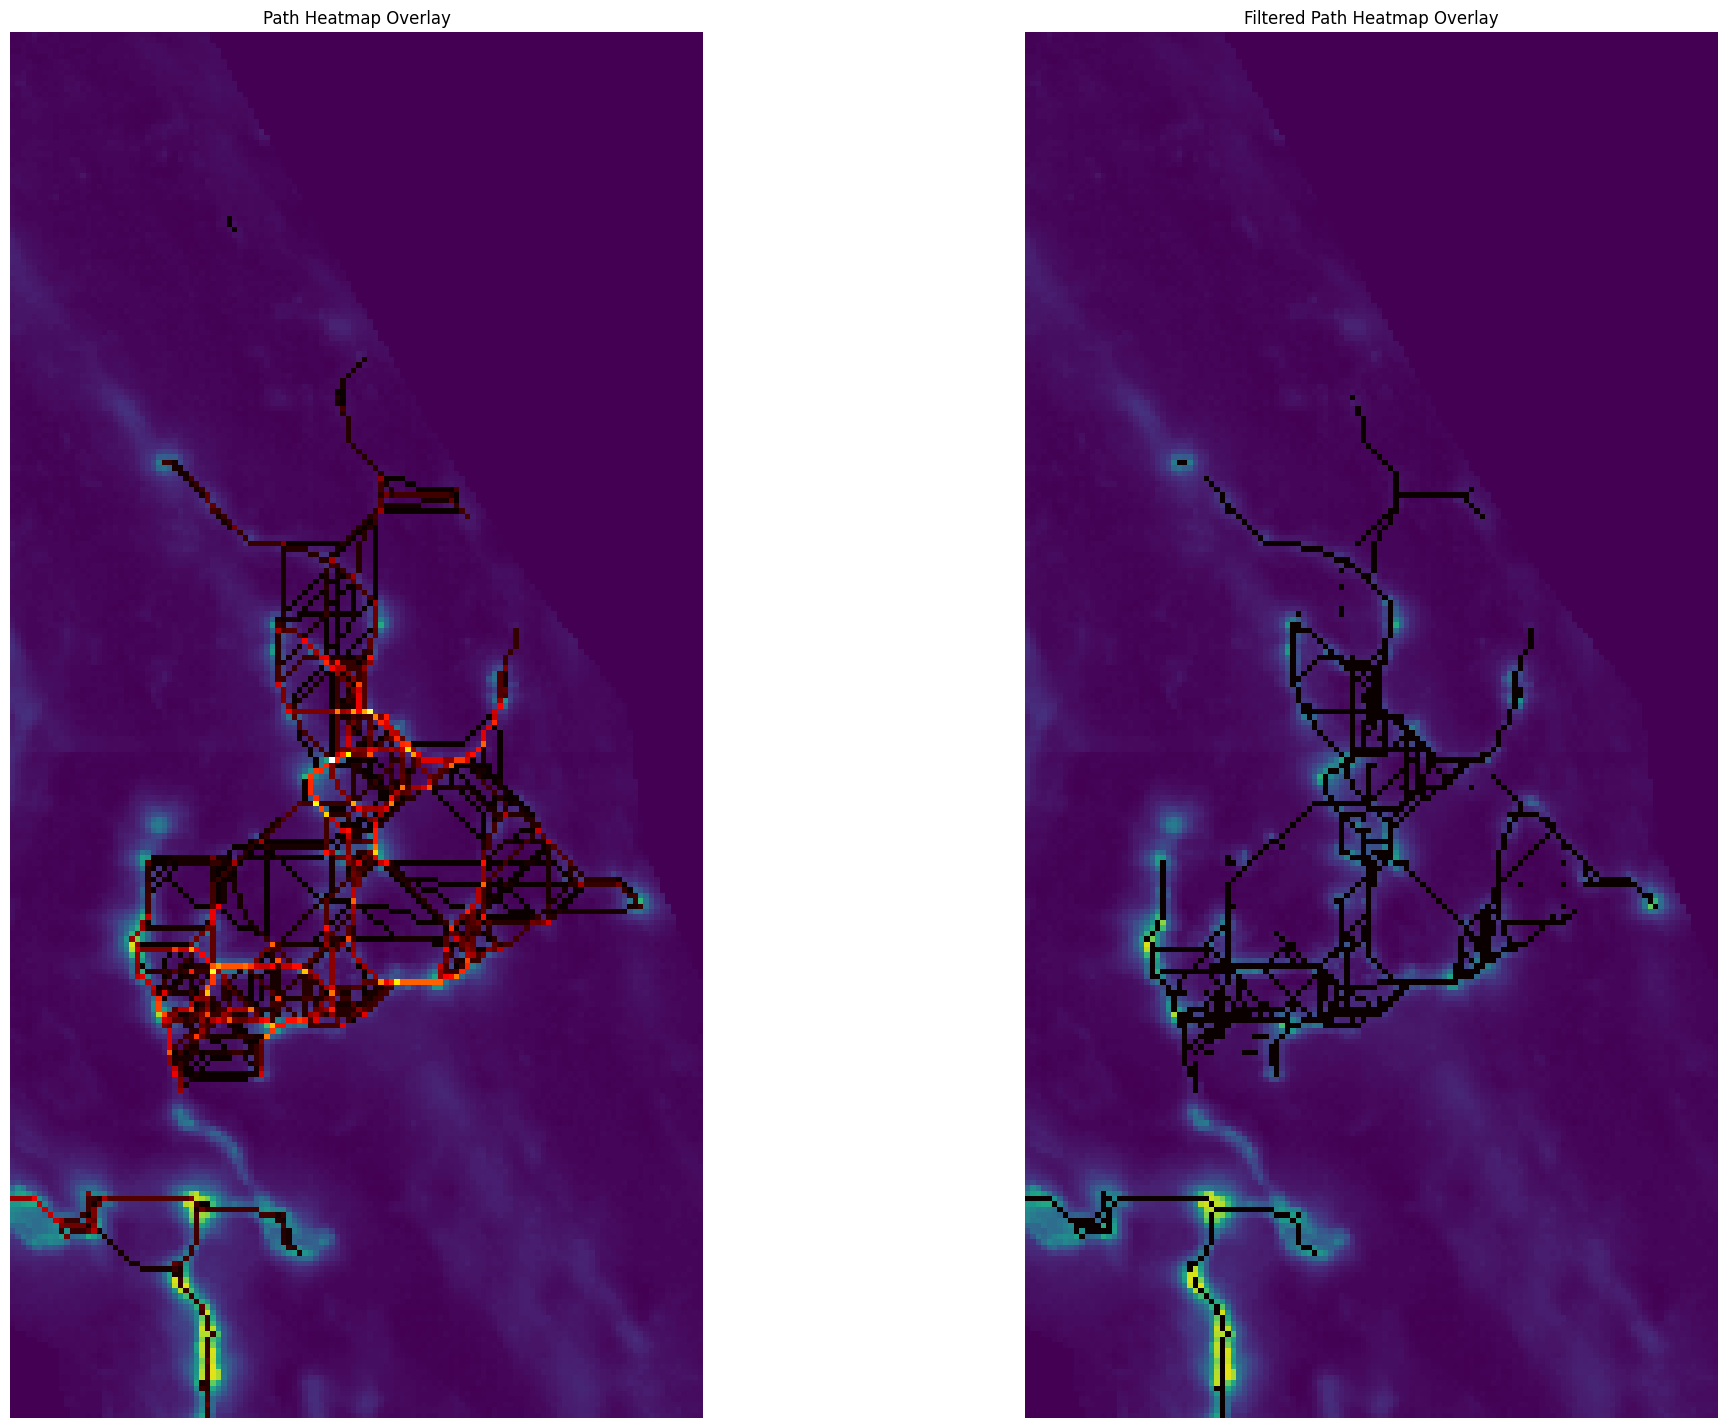

In [ ]:
enhanced_path_heatmap = np.zeros_like(roi_image, dtype=np.float64)
for (p1, p2), (path, cost) in enhanced_parings.items():
    for (py, px) in path:
        enhanced_path_heatmap[py, px] += 1   
_, ax = plt.subplots(1, 2, figsize=(24, 18))

heatmap_ax = ax[0]
heatmap_ax.imshow(roi_image[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
heatmap_ax.imshow(np.ma.masked_where(path_heatmap == 0, path_heatmap)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='hot', alpha=1)
heatmap_ax.set_title("Path Heatmap Overlay")
heatmap_ax.axis('off')


heatmap_thershold = np.quantile(enhanced_path_heatmap[enhanced_path_heatmap > 0], 0.5)
enhanced_filtered_path_heatmap = (enhanced_path_heatmap >= heatmap_thershold).astype(np.uint8)
heatmap_ax2 = ax[1]
heatmap_ax2.imshow(roi_image[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
heatmap_ax2.imshow(np.ma.masked_where(enhanced_filtered_path_heatmap == 0, enhanced_filtered_path_heatmap)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='hot', alpha=1)
heatmap_ax2.set_title("Filtered Path Heatmap Overlay")
heatmap_ax2.axis('off')

plt.show()


In [ ]:
from scipy.ndimage import binary_dilation, generate_binary_structure
    
final_selected_pairs = []
residual_heatmap = path_heatmap.astype(np.float64).copy()

# 動態 threshold：基於 heatmap 的統計特性
stop_threshold = 0.3
suppression_radius = 2  # 抑制半徑
nonzero_heat = residual_heatmap[residual_heatmap > 0]
if len(nonzero_heat) > 0:
    adaptive_threshold = np.percentile(nonzero_heat, 10)  # 第10百分位
    stop_threshold = max(stop_threshold, adaptive_threshold * 0.5)

# 排序
scored_pairs = sorted(enhanced_parings.items(), key=lambda x: x[1][1], reverse=True)
candidates = list(scored_pairs)  # 複製一份

while candidates:
    # 1. 取出當前最高分
    best = candidates.pop(0)
    (s1, s2), (path, score) = best
    
    if len(path) == 0:
        continue
    
    # 2. 檢查剩餘熱度
    path_heat = [residual_heatmap[p] for p in path]
    avg_residual = np.mean(path_heat)
    
    # 也可以用 min 來更嚴格地檢查
    # min_residual = np.min(path_heat)
    
    if avg_residual < stop_threshold:
        continue  # 這條路徑覆蓋的區域已經被選過了
    
    # 3. 接受這條路徑
    final_selected_pairs.append(best)
    
    # 4. 抑制機制
    # 方法 A: 只抑制路徑本身
    # for p in path:
    #     residual_heatmap[p] = 0.0
    
    # 方法 B: 抑制路徑 + 周圍區域（推薦）
    path_mask = np.zeros_like(residual_heatmap, dtype=bool)
    for p in path:
        path_mask[p] = True
    
    if suppression_radius > 0:
        struct = generate_binary_structure(2, 1)  # 4-connectivity
        for _ in range(suppression_radius):
            path_mask = binary_dilation(path_mask, struct)
    
    residual_heatmap[path_mask] = 0.0
    
    # 可選：重新計算剩餘候選的分數（更精確但更慢）
    # candidates = recompute_scores(candidates, residual_heatmap)
    # candidates.sort(key=lambda x: x[3], reverse=True)

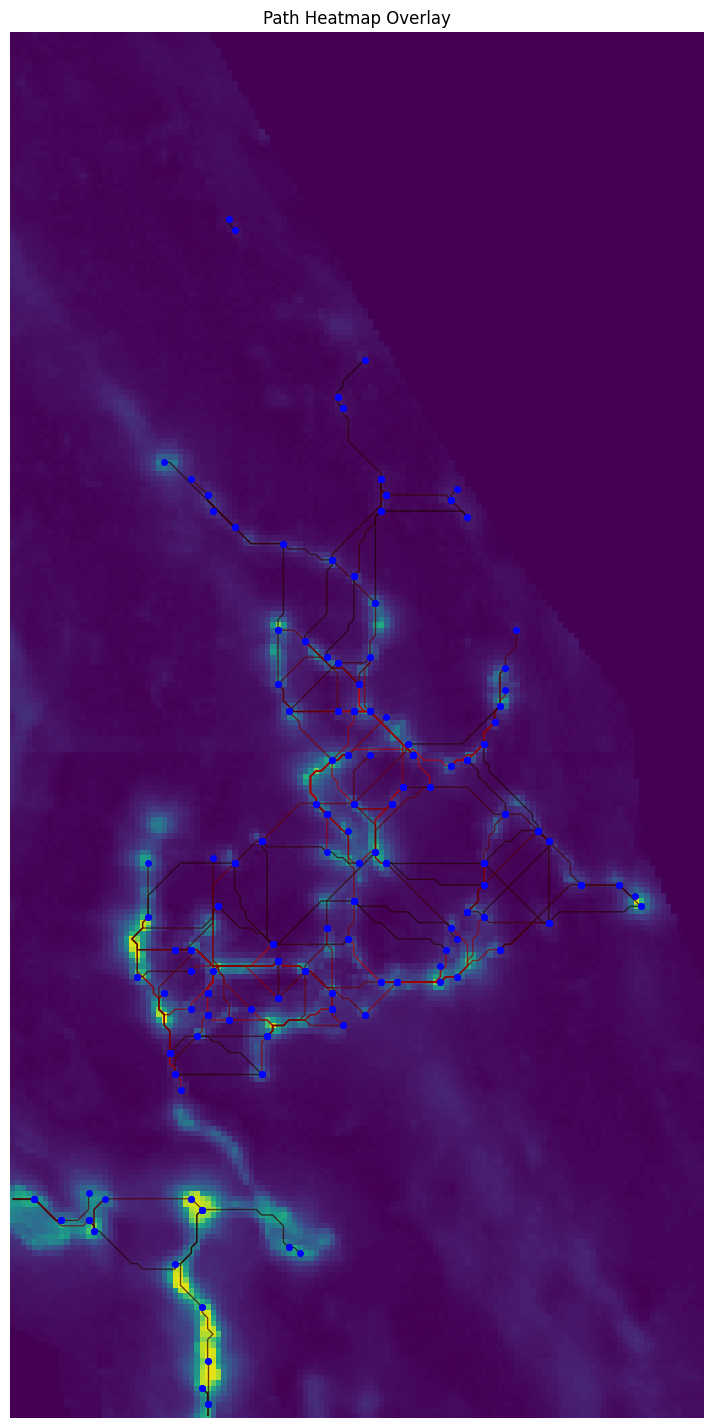

In [ ]:
_, ax = plt.subplots(1, 1, figsize=(24, 18))
import matplotlib.colors as mcolors
all_scores = [score for _, (_, score) in final_selected_pairs]

if all_scores:
    min_score = min(all_scores)
    max_score = max(all_scores)
else:
    min_score, max_score = 0, 1

cmap = plt.get_cmap('hot')
norm = mcolors.Normalize(vmin=min_score, vmax=max_score)

heatmap_ax = ax
heatmap_ax.imshow(roi_image[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W])
for (s1, s2), (path, score) in final_selected_pairs:
    py = []
    px = []
    for (py_i, px_i) in path:
        if py_i < ROI_Y or py_i >= ROI_Y + ROI_H or px_i < ROI_X or px_i >= ROI_X + ROI_W:
            continue
        py.append(py_i - ROI_Y)
        px.append(px_i - ROI_X)

    line_color = cmap(norm(score))
    heatmap_ax.plot(px, py, color=line_color, alpha=0.7, linewidth=1, zorder=1)

    if s1[0] >= ROI_Y and s1[0] < ROI_Y + ROI_H and s1[1] >= ROI_X and s1[1] < ROI_X + ROI_W:
        heatmap_ax.plot(s1[1] - ROI_X, s1[0] - ROI_Y, 'bo', markersize=4, zorder=2)
    if s2[0] >= ROI_Y and s2[0] < ROI_Y + ROI_H and s2[1] >= ROI_X and s2[1] < ROI_X + ROI_W:
        heatmap_ax.plot(s2[1] - ROI_X, s2[0] - ROI_Y, 'bo', markersize=4, zorder=2)
heatmap_ax.set_title("Path Heatmap Overlay")
heatmap_ax.axis('off')

plt.show()


In [ ]:
import networkx as nx
G = nx.Graph()
for (s1, s2), (path, score) in final_selected_pairs:
    G.add_edge(s1, s2, weight=score, path=path)



mst = nx.maximum_spanning_tree(G)

_, ax = plt.subplots(1, 1, figsize=(24, 18))


tree_ax = ax
tree_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
# Draw edges
for u, v, data in mst.edges(data=True):
    # Nodes are expected to be (y, x) tuples from global topology
    y1, x1 = u
    y2, x2 = v

    pt1 = (int(x1), int(y1))
    pt2 = (int(x2), int(y2))

    # If edge data has 'path', draw the full path
    if "path" in data and data["path"]:
            path_points = data["path"]
            # Draw path segments
            py = []
            px = []

            for y_i, x_i in path_points:
                if y_i < ROI_Y or y_i >= ROI_Y + ROI_H or x_i < ROI_X or x_i >= ROI_X + ROI_W:
                    continue
                py.append(y_i - ROI_Y)
                px.append(x_i - ROI_X)

                # py1, px1 = path_points[i]
                # py2, px2 = path_points[i + 1]
                # p1 = (int(px1), int(py1))
                # p2 = (int(px2), int(py2))
            tree_ax.plot(px, py, color='red', alpha=1, linewidth=4)
tree_ax.set_title("MST Reconstruction")
tree_ax.axis('off')

plt.show()
